In [25]:
pip install ensemble

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for ensemble: filename=ensemble-0.0.dev1-py3-none-any.whl size=4424 sha256=1ca3e2b839178b5fe974e3fe86b8cb0098ed6c69fa6788eb77b0850cb288d4bf
  Stored in directory: /root/.cache/pip/wheels/75/45/3c/19a6c90b4cb71bbd300b438922be02ad5cf41b603544c7109e
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=424baa0a8d4fc30638e0a0b38d208c795180006f6ac2da04c5b5b3ad2ee3cca4
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
  Created wheel for pysut: filename=pysut-1.1-py3-none-any.whl size=29061 sha256=c4c11ce8793751cee1e9473d200abb45df46081eea9a6f3e4ea131023ab166e4
  Stored in directory: /root/.cache/pip/wheels/80/cb/e8/d1e97e4d2bc43ccef1428471be4c7d9256d18478f23d0e5692
Successfully built ensemble docopt pysut


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler , MinMaxScaler , LabelEncoder , OneHotEncoder , RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import StackingClassifier , RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [51]:
df = pd.read_csv("/content/creditcard.csv")

In [52]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [53]:
df['Class'].unique()

array([ 0.,  1., nan])

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107046 entries, 0 to 107045
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    107046 non-null  int64  
 1   V1      107046 non-null  float64
 2   V2      107046 non-null  float64
 3   V3      107046 non-null  float64
 4   V4      107046 non-null  float64
 5   V5      107046 non-null  float64
 6   V6      107046 non-null  float64
 7   V7      107046 non-null  float64
 8   V8      107046 non-null  float64
 9   V9      107046 non-null  float64
 10  V10     107046 non-null  float64
 11  V11     107046 non-null  float64
 12  V12     107046 non-null  float64
 13  V13     107046 non-null  float64
 14  V14     107046 non-null  float64
 15  V15     107046 non-null  float64
 16  V16     107046 non-null  float64
 17  V17     107046 non-null  float64
 18  V18     107046 non-null  float64
 19  V19     107046 non-null  float64
 20  V20     107046 non-null  float64
 21  V21     10

In [55]:
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [56]:
df['Class'].value_counts()

,count
Class,
0.0,106810
1.0,235


In [57]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,...,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,107046.000000,107045.000000,107045.000000,107045.000000
mean,44163.193393,-0.257831,-0.026560,0.682250,0.157009,-0.283548,0.098077,-0.116249,0.058826,-0.054332,...,-0.030490,-0.106799,-0.037448,0.010167,0.133350,0.025764,0.001604,0.001640,96.201778,0.002195
std,17718.024713,1.853150,1.647586,1.317292,1.344114,1.348799,1.299593,1.208427,1.232005,1.110405,...,0.741472,0.639652,0.623527,0.595680,0.440034,0.491594,0.391995,0.320114,261.083669,0.046803
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,34238.000000,-1.023275,-0.595414,0.176950,-0.712661,-0.906588,-0.645561,-0.605549,-0.134727,-0.697239,...,-0.224126,-0.533261,-0.176768,-0.323162,-0.130802,-0.323569,-0.061142,-0.005091,7.050000,0.000000
50%,46023.000000,-0.260775,0.078063,0.757881,0.184854,-0.318181,-0.154784,-0.071994,0.077532,-0.121239,...,-0.056729,-0.082983,-0.049385,0.066011,0.171578,-0.069111,0.010696,0.023365,25.150000,0.000000
75%,58413.750000,1.154981,0.738193,1.383324,1.024500,0.244910,0.493216,0.409485,0.369074,0.542787,...,0.120478,0.314211,0.080706,0.407201,0.421048,0.294199,0.084614,0.076725,87.000000,0.000000
max,70256.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,27.202839,10.503090,19.002942,4.016342,5.541598,3.517346,12.152401,33.847808,19656.530000,1.000000


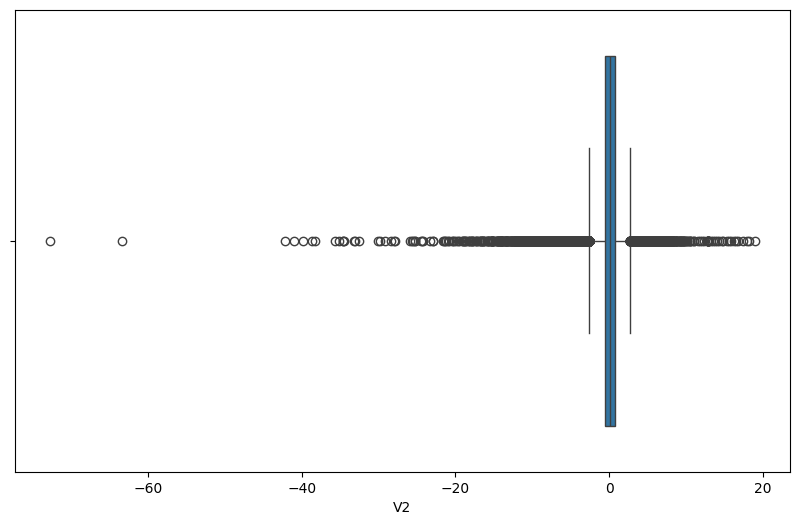

In [58]:
plt.figure(figsize=(10,6))
sns.boxplot(df , x='V2')
plt.show()

In [59]:
df[df['V2']<-15]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2464,2029,-12.168192,-15.732974,-0.376474,3.792613,10.658654,-7.465603,-6.907038,1.573722,0.058164,...,1.660209,-0.910516,0.010468,-0.097246,-0.329918,0.225916,0.201802,-2.368534,120.00,0.0
6812,8592,-23.066842,-25.640527,-3.080313,4.866932,6.901397,-4.074335,2.027345,-2.688652,3.402966,...,-5.378106,3.312971,13.876221,-0.572177,5.525093,0.906980,3.358822,3.553906,845.73,0.0
8610,11621,-27.670569,-34.607649,2.243079,10.463020,34.099309,-23.496714,-26.548144,-0.779134,7.496577,...,-4.651023,-1.627883,-11.669994,2.192626,-2.483069,1.788189,8.254376,-3.509250,55.25,0.0
12851,22573,-18.020508,-25.936137,2.418339,6.553308,24.363532,-16.107178,-17.102376,2.123328,2.670411,...,2.119314,-1.004096,4.865803,-0.348217,0.349188,1.013655,-1.012990,0.410881,15.00,0.0
15364,26752,-28.344757,-40.978852,0.422090,9.264321,23.589804,-17.118592,-14.112878,2.529437,2.104495,...,4.411922,-1.574948,12.045536,-0.327676,2.732898,0.303325,-2.053336,0.897846,2520.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102039,68031,-16.078550,-21.347705,-0.325848,5.817936,14.861542,-9.619438,-10.198322,2.071043,0.755373,...,1.970367,-1.763820,-0.466862,-0.948528,0.120155,-0.596748,0.371814,-3.259195,38.84,0.0
104126,68918,-20.006624,-29.125406,-5.206362,5.936934,3.664480,-5.811355,1.288447,0.581078,-1.583508,...,3.412437,-2.305653,7.437832,0.342376,0.422816,0.503609,-0.553175,-2.691483,3209.39,0.0
104967,69311,-19.004842,-21.255180,-9.294845,6.757810,-14.544709,9.737874,21.915116,-5.120774,-0.129647,...,-3.976238,1.891654,8.671115,0.286375,3.467907,0.465064,3.937467,-0.141533,5303.69,0.0
105026,69333,-21.582209,-28.416644,-8.650537,6.329027,-3.223608,-1.969489,5.892171,-0.769448,-1.115693,...,1.019488,-2.792272,-1.399086,1.104037,-1.064756,0.461778,1.752645,-3.898116,3152.32,0.0


In [60]:
df['Time'].value_counts()

,count
Time,
64947,26
68780,25
3767,21
3770,20
3750,19
...,...
49331,1
49333,1
49334,1


In [61]:
df[df['Time'] >2026]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2461,2028,-0.836395,1.222372,1.589788,0.005322,-0.198704,-1.074656,0.716620,-0.235059,-0.290604,...,-0.153673,-0.495737,0.010515,0.708366,-0.256932,0.010587,-0.136191,0.136858,9.99,0.0
2462,2029,1.073759,0.182407,0.322718,1.358284,-0.275214,-0.706538,0.332380,-0.170687,0.019867,...,0.060641,0.286211,-0.099787,0.635560,0.696497,-0.285847,0.021396,0.024427,49.90,0.0
2463,2029,-0.667367,-0.479007,2.026512,2.240121,-1.785324,1.371491,-1.663363,-2.306503,0.938575,...,-1.155912,0.548137,-0.386310,0.444895,0.750750,-0.058660,0.136507,0.300104,288.45,0.0
2464,2029,-12.168192,-15.732974,-0.376474,3.792613,10.658654,-7.465603,-6.907038,1.573722,0.058164,...,1.660209,-0.910516,0.010468,-0.097246,-0.329918,0.225916,0.201802,-2.368534,120.00,0.0
2465,2030,1.030636,-0.383973,1.314097,0.512020,-1.243026,-0.307822,-0.613874,0.103177,0.815998,...,0.050075,0.214242,0.089289,0.669842,0.013416,0.626491,-0.000224,0.034354,59.16,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107041,70254,-2.953700,2.465992,-0.075277,-1.455576,-1.442560,-0.655782,-0.967306,1.934201,-0.315864,...,0.066515,0.005640,0.225692,0.258676,-0.146257,0.744212,0.200626,0.145780,3.78,0.0
107042,70254,-1.284909,0.367581,1.381822,0.418554,-0.924409,-0.208886,0.908851,0.192367,0.028968,...,-0.091928,-0.178599,0.012480,0.606980,-0.282982,0.184999,-0.238502,-0.276179,175.85,0.0
107043,70254,1.155595,0.262674,0.384212,0.575116,-0.222944,-0.393407,-0.087079,0.066883,-0.250070,...,-0.194424,-0.562963,0.170927,0.184941,0.087174,0.093931,-0.009953,0.019400,1.98,0.0
107044,70255,0.796110,-1.521441,-0.487824,-1.229279,-1.007477,-0.753216,0.216543,-0.325595,0.014072,...,-0.163832,-0.371493,-0.356900,0.106574,0.682830,-0.552729,0.024517,0.066848,306.50,0.0


In [62]:
df['Time'].agg(['min' , 'max' ,  'mean'])

,Time
min,0.000000
max,70256.000000
mean,44163.193393


In [63]:
df.isnull()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
107042,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
107043,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
107044,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [64]:
df.dropna(inplace=True)

In [65]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107040,70254,0.915279,-1.194875,-1.310803,-0.424037,1.407155,3.553645,-0.580181,0.748722,-1.207080,...,-0.339472,-1.203100,-0.169995,0.949019,0.460849,-0.457852,0.004811,0.068037,251.60,0.0
107041,70254,-2.953700,2.465992,-0.075277,-1.455576,-1.442560,-0.655782,-0.967306,1.934201,-0.315864,...,0.066515,0.005640,0.225692,0.258676,-0.146257,0.744212,0.200626,0.145780,3.78,0.0
107042,70254,-1.284909,0.367581,1.381822,0.418554,-0.924409,-0.208886,0.908851,0.192367,0.028968,...,-0.091928,-0.178599,0.012480,0.606980,-0.282982,0.184999,-0.238502,-0.276179,175.85,0.0
107043,70254,1.155595,0.262674,0.384212,0.575116,-0.222944,-0.393407,-0.087079,0.066883,-0.250070,...,-0.194424,-0.562963,0.170927,0.184941,0.087174,0.093931,-0.009953,0.019400,1.98,0.0


In [66]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [67]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107040,70254,0.915279,-1.194875,-1.310803,-0.424037,1.407155,3.553645,-0.580181,0.748722,-1.207080,...,-0.339472,-1.203100,-0.169995,0.949019,0.460849,-0.457852,0.004811,0.068037,251.60,0.0
107041,70254,-2.953700,2.465992,-0.075277,-1.455576,-1.442560,-0.655782,-0.967306,1.934201,-0.315864,...,0.066515,0.005640,0.225692,0.258676,-0.146257,0.744212,0.200626,0.145780,3.78,0.0
107042,70254,-1.284909,0.367581,1.381822,0.418554,-0.924409,-0.208886,0.908851,0.192367,0.028968,...,-0.091928,-0.178599,0.012480,0.606980,-0.282982,0.184999,-0.238502,-0.276179,175.85,0.0
107043,70254,1.155595,0.262674,0.384212,0.575116,-0.222944,-0.393407,-0.087079,0.066883,-0.250070,...,-0.194424,-0.562963,0.170927,0.184941,0.087174,0.093931,-0.009953,0.019400,1.98,0.0


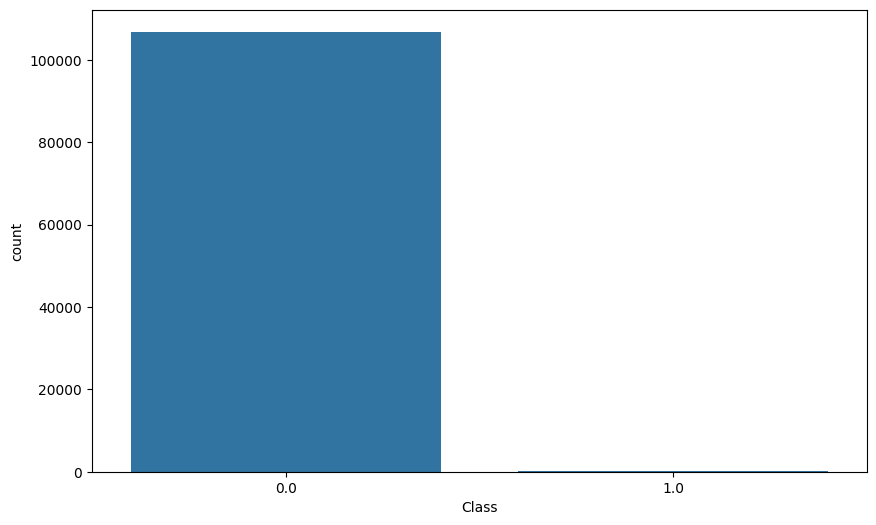

In [68]:
plt.figure(figsize=(10,6))
sns.countplot(x='Class' , data=df)
plt.show()

In [69]:
x = df.drop('Class' , axis=1)
y = df['Class']

In [70]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42 , shuffle=True)

In [71]:
scaler = StandardScaler()

df[['Time' , 'Amount']] = scaler.fit_transform(df[['Time' , 'Amount']])

In [72]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.492569,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.204603,0.0
1,-2.492569,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.358170,0.0
2,-2.492512,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.081874,0.0
3,-2.492512,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.104558,0.0
4,-2.492456,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.100397,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107040,1.472586,0.915279,-1.194875,-1.310803,-0.424037,1.407155,3.553645,-0.580181,0.748722,-1.207080,...,-0.339472,-1.203100,-0.169995,0.949019,0.460849,-0.457852,0.004811,0.068037,0.595207,0.0
107041,1.472586,-2.953700,2.465992,-0.075277,-1.455576,-1.442560,-0.655782,-0.967306,1.934201,-0.315864,...,0.066515,0.005640,0.225692,0.258676,-0.146257,0.744212,0.200626,0.145780,-0.353995,0.0
107042,1.472586,-1.284909,0.367581,1.381822,0.418554,-0.924409,-0.208886,0.908851,0.192367,0.028968,...,-0.091928,-0.178599,0.012480,0.606980,-0.282982,0.184999,-0.238502,-0.276179,0.305069,0.0
107043,1.472586,1.155595,0.262674,0.384212,0.575116,-0.222944,-0.393407,-0.087079,0.066883,-0.250070,...,-0.194424,-0.562963,0.170927,0.184941,0.087174,0.093931,-0.009953,0.019400,-0.360889,0.0


In [73]:
smotte = SMOTE(random_state=42)
x_smote , y_smote = smotte.fit_resample(x_train , y_train)

In [88]:
print(y_smote.value_counts())

Class
0.0    85450
1.0    85450
Name: count, dtype: int64


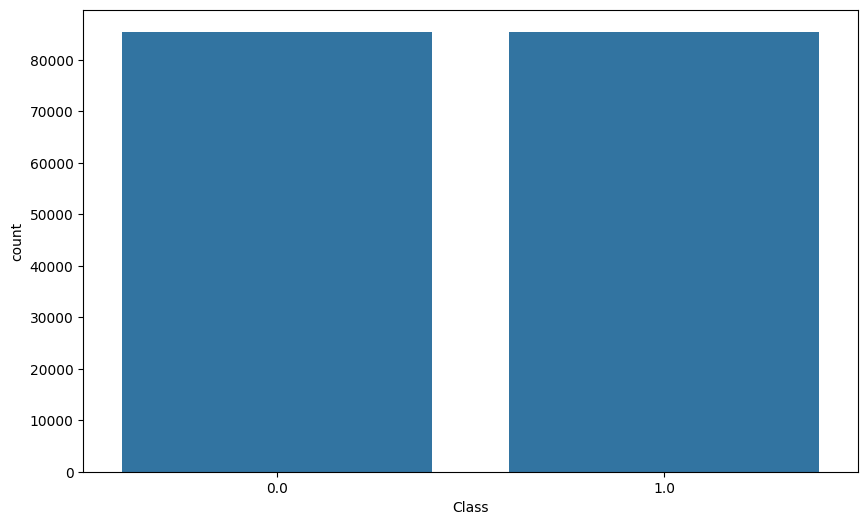

In [94]:
plt.figure(figsize=(10,6))
sns.countplot(x=y_smote)
plt.show()

In [78]:
model = [
    (
        'XBG' , XGBClassifier()
    ) ,
    (
        'rf' , RandomForestClassifier()
    )
]

final = LogisticRegression()

models = StackingClassifier(estimators=model ,
                            final_estimator=final,
                            cv=5)

In [80]:
models.fit(x_smote , y_smote)

StackingClassifier(cv=5,
                   estimators=[('XBG',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_...raints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('rf', RandomForestClassifier())],
                   final_estimator=LogisticRegression())

In [81]:
y_pred = models.predict(x_test)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

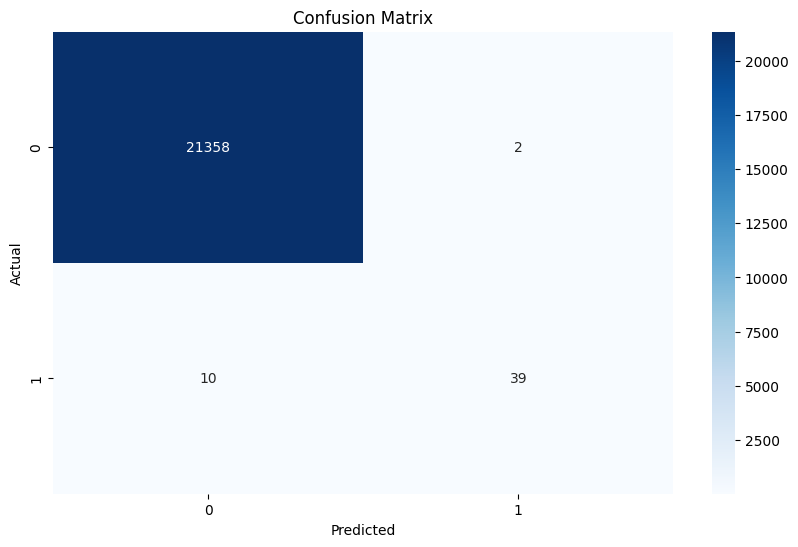

In [82]:
plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test , y_pred)
sns.heatmap(cm , annot=True , fmt='d' , cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [84]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     21360
         1.0       0.95      0.80      0.87        49

    accuracy                           1.00     21409
   macro avg       0.98      0.90      0.93     21409
weighted avg       1.00      1.00      1.00     21409



In [97]:
joblib.dump(models , "Credit Card.pkl")

['Credit Card.pkl']

In [99]:
import joblib

# احفظ الموديل والـ سكيلر في فولدر الـ Colab
joblib.dump(models, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']